In [1]:
import numpy as np
import tensorflow as tf
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from vae.vae_words_model import WordVAE, KLAnnealingCallback, encode_word, decode_output, MAX_LEN, VOCAB_SIZE
import matplotlib.pyplot as plt
import umap


In [2]:
LATENT_DIM = 32
EPOCHS = 30
BATCH_SIZE = 256
KL_WARMUP_EPOCHS = 15  # beta ramps from 0 -> 1 over the first 15 epochs

In [3]:
print("Loading word list...")
with open("/usr/share/dict/words") as f:
#with open("../assets/names.txt") as f:
    raw_words = [w.strip() for w in f]

Loading word list...


In [4]:
# Keep only all-alpha words up to MAX_LEN characters
words = [w.lower() for w in raw_words if w.isalpha() and 1 <= len(w) <= MAX_LEN]
print(f"  {len(words):,} words after filtering (max length {MAX_LEN})")

  198,537 words after filtering (max length 12)


In [5]:
# Encode to flat one-hot vectors  shape: (N, MAX_LEN * VOCAB_SIZE)
print("Encoding words...")
x_words = np.array([encode_word(w) for w in words], dtype="float32")
print(f"  Dataset shape: {x_words.shape}")

Encoding words...
  Dataset shape: (198537, 324)


In [6]:
# Train / validation split (90 / 10)
split = int(len(x_words) * 0.9)
x_train, x_val = x_words[:split], x_words[split:]

In [7]:
vae = WordVAE(latent_dim=LATENT_DIM)
vae.compile(optimizer=Adam(learning_rate=0.001))

In [8]:
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1,
)

print(f"\nTraining WordVAE  (latent_dim={LATENT_DIM}, epochs={EPOCHS})..")
history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, x_val),
    callbacks=[KLAnnealingCallback(warmup_epochs=KL_WARMUP_EPOCHS), lr_scheduler],
)



Training WordVAE  (latent_dim=32, epochs=30)..
Epoch 1/30
698/698 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - beta: 0.0667 - kl_loss: 45.4290 - loss: 10.8329 - reconstruction_loss: 7.8043 - val_beta: 0.0667 - val_kl_loss: 40.5606 - val_loss: 29.5344 - val_reconstruction_loss: 26.8304 - learning_rate: 0.0010
Epoch 2/30
698/698 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - beta: 0.1333 - kl_loss: 38.6888 - loss: 10.0105 - reconstruction_loss: 4.8520 - val_beta: 0.1333 - val_kl_loss: 36.0693 - val_loss: 28.8960 - val_reconstruction_loss: 24.0867 - learning_rate: 0.0010
Epoch 3/30
698/698 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - beta: 0.2000 - kl_loss: 34.1824 - loss: 11.5150 - reconstruction_loss: 4.6785 - val_beta: 0.2000 - val_kl_loss: 32.8881 - val_loss: 29.8606 - val_reconstruction_loss: 23.2830 - learning_rate: 0.0010
Epoch 4/30
698/698 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - beta: 0.2667 - kl_loss: 32.1526 - loss: 12.1849 - reconstruction_loss: 3.6109 - val_beta: 0.2667 - val_kl_loss: 30.7428 - val_loss: 31.

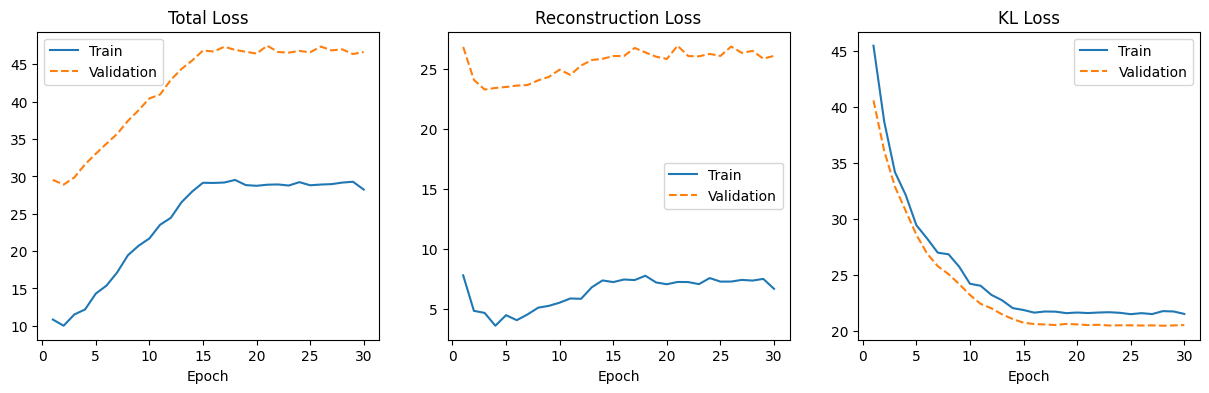

In [9]:
epochs_range = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(
    axes,
    ["loss", "reconstruction_loss", "kl_loss"],
    ["Total Loss", "Reconstruction Loss", "KL Loss"],
):
    ax.plot(epochs_range, history.history[key], label="Train")
    ax.plot(epochs_range, history.history[f"val_{key}"], label="Validation", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

In [10]:
# ---------------------------------------------------------------------------
# Sample random words from the prior
# ---------------------------------------------------------------------------
print("\n--- 30 randomly generated words ---")
z_random = np.random.normal(size=(30, LATENT_DIM)).astype("float32")
generated = vae.decoder.predict(z_random, verbose=0)  # (30, MAX_LEN, VOCAB_SIZE)
for i, g in enumerate(generated):
    word = decode_output(g)
    print(f"  {i+1:2d}: {word}")


--- 30 randomly generated words ---
   1: bletari
   2: anandi
   3: euticocation
   4: aubeermorfha
   5: cogdetio
   6: doriaist
   7: tarurist
   8: pugnlys
   9: bysthu
  10: cackult
  11: temegtauslly
  12: inccdellasce
  13: calcinerme
  14: nhech
  15: dlrrisd
  16: orefgatoridy
  17: marcfrik
  18: teyseit
  19: durtin
  20: bruble
  21: treferater
  22: leudianshum
  23: alghre
  24: manf ith
  25: motipolitiat
  26: leniatry
  27: scebais  s
  28: nelvirceat
  29: picont
  30: frustnont


In [19]:
# Interpolation between two real words
word_a, word_b = "dragon", "castle"
steps = 8

za = vae.encoder.predict(
    np.array([encode_word(word_a)], dtype="float32"), verbose=0
)[0]  # z_mean
zb = vae.encoder.predict(
    np.array([encode_word(word_b)], dtype="float32"), verbose=0
)[0]

print(f"\n--- Latent interpolation: '{word_a}' → '{word_b}' ---")
for t in np.linspace(0, 1, steps):
    z_interp = (1 - t) * za + t * zb
    out = vae.decoder.predict(z_interp, verbose=0)[0]
    print(f"  t={t:.2f}  →  {decode_output(out)}")


--- Latent interpolation: 'dragon' → 'castle' ---
  t=0.00  →  dragon
  t=0.14  →  dragon
  t=0.29  →  drago
  t=0.43  →  dorti
  t=0.57  →  carti
  t=0.71  →  castle
  t=0.86  →  castle
  t=1.00  →  castle


/Users/aydin/Documents/Code/mnist_vae/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


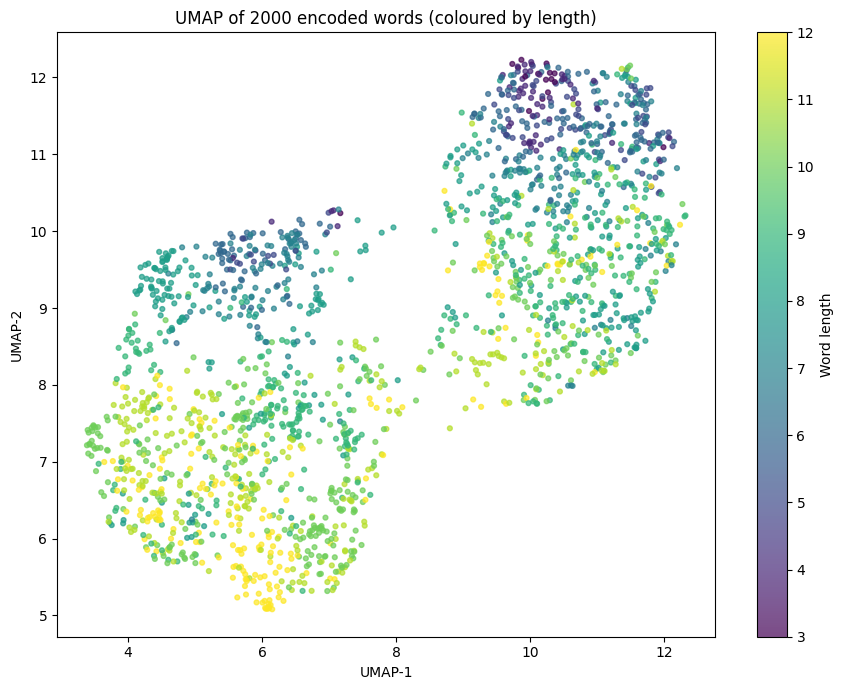

In [20]:

n_sample = min(2000, len(x_val))
indices = np.random.choice(len(x_val), n_sample, replace=False)
x_sample = x_val[indices]

z_mean, _, _ = vae.encoder.predict(x_sample, verbose=0)

# Colour by word length (easy proxy label)
word_lengths = np.array([len(decode_output(x_words[split + i])) for i in indices])

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
z_2d = reducer.fit_transform(z_mean)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=word_lengths, cmap="viridis", s=12, alpha=0.7)
plt.colorbar(sc, ax=ax, label="Word length")
ax.set_title(f"UMAP of {n_sample} encoded words (coloured by length)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
plt.tight_layout()
plt.show()

In [21]:
vae.save("../Data/vae_words.keras")
print("\nModel saved: vae_words.keras")


Model saved: vae_words.keras


/Users/aydin/Documents/Code/mnist_vae/.venv/lib/python3.13/site-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)
